In [220]:
from probjax.nn.helpers import TimeEmbedding 
from probjax.distributions import Normal, Independent
import haiku as hk

import matplotlib.pyplot as plt

import optax
from optax import adam

import jax
import jax.numpy as jnp


In [221]:
# Mixture of Gaussians target distribution
input_dim = 2
p = Independent(Normal(jnp.zeros(input_dim), jnp.ones(input_dim)), 1)
target_samples1 = p.sample(jax.random.PRNGKey(0), (5000,)) + 5.0
target_samples2 = p.sample(jax.random.PRNGKey(1), (5000,)) - 5.0
xs = jnp.concatenate([target_samples1, target_samples2], axis=0)


# Discrete Models i.e. DDPM

>The diffusion process is fixed to a **Markov chain** that gradually adds Gaussian noise to the data according to a **variance schedule** $\beta_1, \beta_2...\beta_T$ where $\beta_1<\beta_2...<\beta_T$

$$
q(x_{1:T} ∣x_0)=\prod_{t=1}^{T} q(x_t∣x_{t−1})
$$
Where we define
$$
q(x_t ∣ x_{t−1})=\mathcal{N}(x_t; \sqrt{1−\beta_t} x_{t−1},\beta_t I)
$$

For training we will need $q(x_t|x_0)$ for all the possible $t$. Which can be shown to be
$$
\alpha_t:=1−β_t
$$

$$
\bar\alpha_t:=\prod_{s=1}^{T} \alpha_s
$$

$$
q(x_t ∣ x_0)=\mathcal{N}(x_t; \sqrt{\bar\alpha_t} x_0,(1−\bar\alpha_t)I)
$$

In [222]:
time_steps = 200

betas = jnp.linspace(0.000001, 0.05, time_steps)


alpha = 1- betas
alpha_bar = jnp.cumprod(alpha)
alpha_bar = jnp.concatenate((jnp.array([1.]), alpha_bar[:-1]), axis=0)
sqrt_alpha_bar = jnp.sqrt(alpha_bar)
one_minus_sqrt_alpha_bar = jnp.sqrt(1 - alpha_bar)


def ddpm_forward(key, x, t):
    noise = jax.random.normal(key, x.shape)
    x_noised = x * jnp.take(sqrt_alpha_bar, t) + noise * jnp.take(one_minus_sqrt_alpha_bar,t)
    return x_noised, noise

def noise_fn(key, x):
    for t in range(time_steps):
        key, subkey = jax.random.split(key)
        x, _ = ddpm_forward(subkey, x, t)
    return x

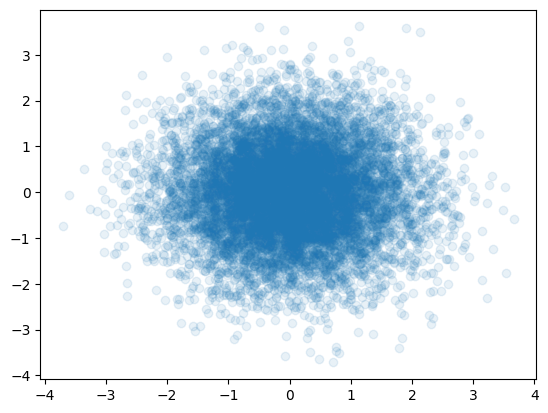

In [223]:
xs_noised = noise_fn(jax.random.PRNGKey(0), xs)

plt.scatter(xs_noised[:, 0], xs_noised[:, 1], alpha=0.1)

The network is trained as following

$$Loss_{simplified}(\theta) = \mathbb{E_{t, x_0, \epsilon}}[||\epsilon - \epsilon_\theta(\sqrt{\bar\alpha_t} x_{0}+ \sqrt{1-\bar\alpha_t}\epsilon,t)||^2] \hspace{0.5cm} \epsilon \in \mathcal{N}(0, I)$$

In [224]:
def forward(x, t):
    time_emb = TimeEmbedding(dim=4)
    x_concat = jnp.concatenate([x, time_emb(t)], axis=-1)
    return hk.nets.MLP([100,100,100, 2])(x_concat)


init, model = hk.without_apply_rng(hk.transform(forward))
params = init(jax.random.PRNGKey(42), jnp.ones((1, 2)), jnp.ones((1, 1)))

In [225]:
def loss_fn(params, key,samples, batch_size= 1024):
    rng_time, rng_sample, rng_batch = jax.random.split(key, 3)
    batch_xs = jax.random.choice(rng_batch, samples, shape=(batch_size, ), axis=0)
    times = jax.random.randint(rng_time, (batch_size, 1), 0, time_steps)

    # Forward diffusion
    batch_noisy_xs, batch_noise = ddpm_forward(rng_sample, batch_xs, times)

    # Predict noise
    batch_pred_noise = model(params, batch_noisy_xs, times)

    # Loss
    loss = jnp.mean(jnp.sum((batch_noise - batch_pred_noise) ** 2, axis=-1))
    return loss


optimizer = adam(1e-3)
opt_state = optimizer.init(params)

@jax.jit
def step(params, key, opt_state, x):
    loss, g = jax.value_and_grad(loss_fn)(params,key, x)
    updates, updated_state = optimizer.update(g, opt_state)
    new_params = optax.apply_updates(params, updates)

    return new_params, updated_state, loss


In [226]:
key = jax.random.PRNGKey(42)
for i in range(10000):
    key, subkey = jax.random.split(key)
    params, opt_state, loss = step(params, subkey,opt_state, xs)
    if i % 1000 == 0:
        print(loss)

2.4541574
1.3327076
1.3031828
1.2487583
1.0576245
1.000214
0.9118146
0.97214293
0.93162477
0.9733399


Inference is then done by:

<center><img src="https://i.imgur.com/jFkkmXc.png" width=400px></center>

In [227]:
def ddpm_backward(key, x, t):
    alpha_t = jnp.take(alpha, t)
    alpha_t_bar = jnp.take(alpha_bar, t)

    eps_coef = (1 - alpha_t) / (1 - alpha_t_bar) ** .5 
    pred_noise = model(params, x, t) 
    mean = 1 / (alpha_t ** 0.5) * (x - eps_coef * pred_noise)
  
    var = jnp.take(betas, t)
    z = jax.random.normal(key=key, shape=x.shape)

    return mean + (var ** 0.5) * z

In [228]:

def sample_fn(params, key, shape):
    x_T = jax.random.normal(key, shape)

    for t in range(time_steps - 1, 0, -1):
        time = jnp.ones(shape[:-1] + (1,), dtype=int) * t
        x_T = ddpm_backward(key, x_T, time)
    return x_T

In [229]:
samples = sample_fn(params, jax.random.PRNGKey(42), (1000, 2))

(-10.0, 10.0)

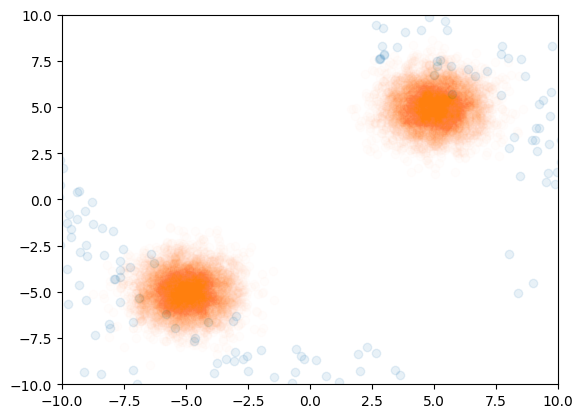

In [230]:
plt.scatter(samples[:, 0], samples[:, 1], alpha=0.1)
plt.scatter(xs[:, 0], xs[:, 1], alpha=0.01)
plt.xlim(-10, 10)
plt.ylim(-10, 10)


# Continous models i.e. score-based diffusion model

Here the time $t$ is considered to be continous


Now let's get our hands dirty on training. First of all, we need to specify an SDE that perturbs the data distribution $p_0$ to a prior distribution $p_T$. We choose the following SDE
\begin{align*}
d \mathbf{x} = \sigma^t d\mathbf{w}, \quad t\in[0,1]
\end{align*}
In this case,
\begin{align*}
p_{0t}(\mathbf{x}(t) \mid \mathbf{x}(0)) = \mathcal{N}\bigg(\mathbf{x}(t); \mathbf{x}(0), \frac{1}{2\log \sigma}(\sigma^{2t} - 1) \mathbf{I}\bigg)
\end{align*}
and we can choose the weighting function $\lambda(t) = \frac{1}{2 \log \sigma}(\sigma^{2t} - 1)$.

When $\sigma$ is large, the prior distribution, $p_{t=1}$ is 
\begin{align*}
\int p_0(\mathbf{y})\mathcal{N}\bigg(\mathbf{x}; \mathbf{y}, \frac{1}{2 \log \sigma}(\sigma^2 - 1)\mathbf{I}\bigg) d \mathbf{y} \approx \mathbf{N}\bigg(\mathbf{x}; \mathbf{0}, \frac{1}{2 \log \sigma}(\sigma^2 - 1)\mathbf{I}\bigg),
\end{align*}
which is approximately independent of the data distribution and is easy to sample from.


\begin{align}
&\min_\theta \mathbb{E}_{t\sim \mathcal{U}(0, T)} [\lambda(t) \mathbb{E}_{\mathbf{x}(0) \sim p_0(\mathbf{x})}\mathbf{E}_{\mathbf{x}(t) \sim p_{0t}(\mathbf{x}(t) \mid \mathbf{x}(0))}[ \|s_\theta(\mathbf{x}(t), t) - \nabla_{\mathbf{x}(t)}\log p_{0t}(\mathbf{x}(t) \mid \mathbf{x}(0))\|_2^2]], \\
 = & \min_\theta \mathbb{E}_{t\sim \mathcal{U}(0, T)} [\lambda(t) \mathbb{E}_{\mathbf{x}(0) \sim p_0(\mathbf{x})}\mathbf{E}_{\mathbf{x}(t) \sim p_{0t}(\mathbf{x}(t) \mid \mathbf{x}(0))}[ ||s_\theta(\mathbf{x}(t), t)  + (x_t - x_0)/\sigma_t^2] ||_2^2
\end{align}

Note that $x_t = x_0 + \sqrt{\sigma_t^2} \epsilon$. Hence we can simplify $x_t - x_0 = \sqrt{\sigma_t^2}  \epsilon $

In [244]:
T = 1.
sigma= 5.

def drift_fn(x, t):
    return 0. 

def diffusion_fn(x, t):
    return sigma**t

def marginal_std(x, t):
    return jnp.sqrt(1/(2*jnp.log(sigma)) * (sigma**(2*t) - 1))


def sbd_forward(key, x0, t):
    noise = jax.random.normal(key, x0.shape)
    std = marginal_std(x0, t)
    x_noised = x0 + std * noise
    return x_noised, noise

In [245]:
def forward(x, t):
    time_emb = TimeEmbedding(dim=4)
    x_concat = jnp.concatenate([x, time_emb(t)], axis=-1)
    return hk.nets.MLP([100,100,100, 2], activation=jax.nn.tanh)(x_concat)


init, model = hk.without_apply_rng(hk.transform(forward))
params = init(jax.random.PRNGKey(42), jnp.ones((1, 2)), jnp.ones((1, 1)))

In [246]:
def loss_fn(params, key,samples, batch_size= 1024):
    rng_time, rng_sample, rng_batch = jax.random.split(key, 3)
    batch_xs = jax.random.choice(rng_batch, samples, shape=(batch_size, ), axis=0)
    times = jax.random.uniform(rng_time, (batch_size, 1), minval=1e-6, maxval=1.0)

    # Forward diffusion
    batch_noisy_xs, batch_noise = sbd_forward(rng_sample, batch_xs, times)
    std = marginal_std(batch_xs, times)
    # Predict noise
    batch_pred_noise = model(params, batch_noisy_xs, times)

    # Loss
    loss = jnp.mean(jnp.sum((batch_pred_noise + 1/std * batch_noise) ** 2, -1))
    return loss


optimizer = adam(1e-3)
opt_state = optimizer.init(params)

@jax.jit
def step(params, key, opt_state, x):
    loss, g = jax.value_and_grad(loss_fn)(params,key, x)
    updates, updated_state = optimizer.update(g, opt_state)
    new_params = optax.apply_updates(params, updates)

    return new_params, updated_state, loss


In [247]:
key = jax.random.PRNGKey(42)
for i in range(10000):
    key, subkey = jax.random.split(key)
    params, opt_state, loss = step(params, subkey,opt_state, xs)
    if i % 1000 == 0:
        print(loss)

38.09699
11.992956
16.79992
367.96094
25.6546
8.991583
13.754177
15.827483
7.520921
16.086834


In [248]:
x, y = jnp.meshgrid(jnp.arange(-8, 8, 0.5), jnp.arange(-8, 8, 0.5))
pos = jnp.dstack((x, y)).reshape(-1, 2)
vs = model(params, pos, jnp.ones((pos.shape[0], 1)) * 0.01)

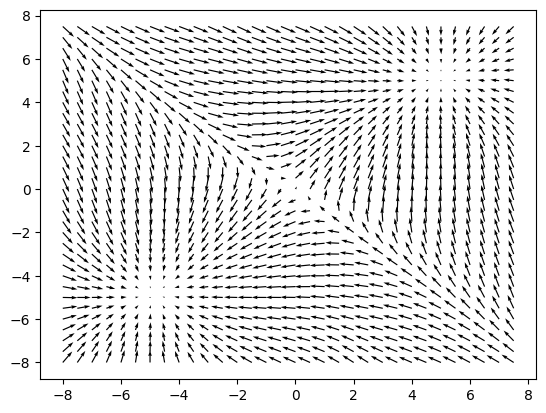

In [249]:
plt.quiver(pos[:, 0], pos[:, 1], vs[:, 0], vs[:, 1], scale=100)

## Sampling with Numerical SDE Solvers
Recall that for any SDE of the form
\begin{align*}
d \mathbf{x} = \mathbf{f}(\mathbf{x}, t) dt + g(t) d\mathbf{w},
\end{align*}
the reverse-time SDE is given by
\begin{align*}
d \mathbf{x} = [\mathbf{f}(\mathbf{x}, t) - g(t)^2 \nabla_\mathbf{x} \log p_t(\mathbf{x})] dt + g(t) d \bar{\mathbf{w}}.
\end{align*}
Since we have chosen the forward SDE to be
\begin{align*}
d \mathbf{x} = \sigma^t d\mathbf{w}, \quad t\in[0,1]
\end{align*}
The reverse-time SDE is given by
\begin{align*}
d\mathbf{x} = -\sigma^{2t} \nabla_\mathbf{x} \log p_t(\mathbf{x}) dt + \sigma^t d \bar{\mathbf{w}}.
\end{align*}
To sample from our time-dependent score-based model $s_\theta(\mathbf{x}, t)$, we first draw a sample from the prior distribution $p_1 \approx \mathbf{N}\bigg(\mathbf{x}; \mathbf{0}, \frac{1}{2}(\sigma^{2} - 1) \mathbf{I}\bigg)$, and then solve the reverse-time SDE with numerical methods.

In particular, using our time-dependent score-based model, the reverse-time SDE can be approximated by
\begin{align*}
d\mathbf{x} = -\sigma^{2t} s_\theta(\mathbf{x}, t) dt + \sigma^t d \bar{\mathbf{w}}
\end{align*}

Next, one can use numerical methods to solve for the reverse-time SDE, such as the [Euler-Maruyama](https://en.wikipedia.org/wiki/Euler%E2%80%93Maruyama_method) approach. It is based on a simple discretization to the SDE, replacing $dt$ with $\Delta t$ and $d \mathbf{w}$ with $\mathbf{z} \sim \mathcal{N}(\mathbf{0}, g^2(t) \Delta t \mathbf{I})$. When applied to our reverse-time SDE, we can obtain the following iteration rule
\begin{align}
\mathbf{x}_{t-\Delta t} = \mathbf{x}_t + \sigma^{2t} s_\theta(\mathbf{x}_t, t)\Delta t + \sigma^t\sqrt{\Delta t} \mathbf{z}_t,
\end{align}
where $\mathbf{z}_t \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$.

In [250]:
def sample_fn(params, key, shape, time_steps=1000):
    x_T = jax.random.normal(key, shape) * marginal_std(jnp.zeros(shape), 1)
    ts = jnp.linspace(1, 1e-6, time_steps)
    time_steps = ts[0] - ts[1]
    for t in ts:
        time = jnp.ones(shape[:-1] + (1,), dtype=int) * t
        score = model(params, x_T, time)
        g = diffusion_fn(x_T, t)
        f = drift_fn(x_T, t)
        subkey, key = jax.random.split(key)
        noise = jax.random.normal(subkey, shape)
        x_T = x_T - ((f - g**2 * score)*time_steps + g * noise * jnp.sqrt(time_steps))
    return x_T

In [251]:
samples = sample_fn(params, jax.random.PRNGKey(42), (1000, 2))

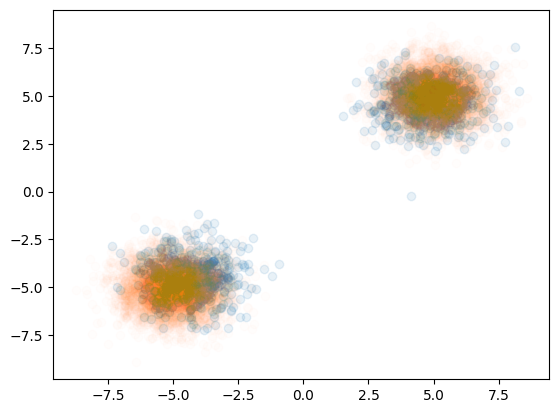

In [252]:
plt.scatter(samples[:, 0], samples[:, 1], alpha=0.1)
plt.scatter(xs[:, 0], xs[:, 1], alpha=0.01)


In [3]:
import jax.numpy as jnp
from jax import lax

def get_spaced_elements(arr, spacing):
    # Initialize the output array with the first element of the input array
    out = jnp.array([arr[0]])

    # Define the scan function
    def scan_fn(carry, x):
        prev, out = carry
        dist = x - prev
        new_out = jnp.where(dist >= spacing, jnp.append(out, x), out)
        return (x, new_out), (x, new_out)

    # Call lax.scan to iterate over the input array and add elements to the output array
    _, out = lax.scan(scan_fn, (arr[0], out), arr[1:])

    return out

In [4]:
ts = jnp.linspace(0, 1, 10)
ts = get_spaced_elements(ts, 0.01)

TypeError: Scanned function carry input and carry output must have equal types (e.g. shapes and dtypes of arrays), but they differ:
  * the input carry component carry[1] has type float32[1] but the corresponding output carry component has type float32[2], so the shapes do not match

Revise the scanned function so that all output types (e.g. shapes and dtypes) match the corresponding input types.